# CMAPSS FD001: Exploratory Data Analysis

I start here, before any features or models, with three questions. What do the raw sensors look like? Which channels actually move with degradation? What does the remaining-useful-life label look like, and does the 125-cycle cap earn its place?

NASA CMAPSS FD001 is 100 turbofan engines run to failure under one operating condition and one fault mode: high-pressure compressor (HPC) degradation. Each cycle records 21 sensors and 3 operating settings. Training gives the full run-to-failure sequence. The test set gives a truncated sequence plus the true RUL at the last observed cycle.

Section 3's variance analysis is what `src/features.py` uses to drop uninformative sensors. Section 6's trajectories are why I use a rolling window instead of a raw reading.

**Before running:** put these space-separated, no-header files in `data/raw/`:
- `train_FD001.txt`
- `test_FD001.txt`
- `RUL_FD001.txt`

Sources: [NASA PCOE](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/) or the [Kaggle mirror](https://www.kaggle.com/datasets/behrad3d/nasa-cmaps).

**Environment:** `conda activate cmapss-rul` from the project root, then open this notebook with the `cmapss-rul` kernel.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Project root (works whether cwd is repo root or notebooks/)
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RAW = ROOT / "data" / "raw"
sys.path.insert(0, str(ROOT))

from src.features import COLUMNS, CONSTANT_SENSORS, load_raw, add_rul
from src.utils import plot_degradation_trajectories, plot_rul_distribution

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

print("ROOT:", ROOT)
print("RAW:", RAW)

ROOT: /sessions/gracious-nifty-hamilton/mnt/cmapss_rul
RAW: /sessions/gracious-nifty-hamilton/mnt/cmapss_rul/data/raw


## 1. Load the Raw Data

The raw `.txt` files have no column headers. `load_raw()` assigns them. The 26 columns are `unit` (engine ID), `cycle` (time step), three operating settings, and 21 sensor channels. `add_rul()` sets each row's label to `(max_cycle_for_that_engine - current_cycle)`, then clips at 125.

In the head output below, `op_setting_3` is always 100.0 because FD001 is a single operating condition, and several sensor columns look constant. Section 3 measures that.

In [2]:
required = ["train_FD001.txt", "test_FD001.txt", "RUL_FD001.txt"]
missing = [f for f in required if not (RAW / f).exists()]
if missing:
    raise FileNotFoundError(
        f"Missing in {RAW}: {missing}. Download FD001 from NASA PCOE or Kaggle and copy files here."
    )
print("All FD001 raw files present.")

All FD001 raw files present.


In [3]:
train_path = RAW / "train_FD001.txt"
train = load_raw(train_path)
train_labeled = add_rul(train.copy())

print(train.shape)
print("Engines:", train["unit"].nunique())
display(train.head())

(20631, 26)
Engines: 100


,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Engine Lifetime Distribution

The histogram below shows how many cycles each of the 100 training engines ran before failure. Run lengths span a wide range, including a long right tail of engines that last 300+ cycles. A model that ignores sensors and always guesses the average life will be off by tens of cycles. That spread is an EDA fact, not the score I report. The baseline I actually train and compare against is Ridge regression under the same split and RUL cap (17.47 RMSE on the official FD001 test set).

The piecewise-linear RUL label clips everything above 125, so an engine early in a 300-cycle run gets the same label as an engine at cycle 50 of a 128-cycle run. That is intentional: I want the model to spend capacity on late-stage degradation, not on telling healthy engines apart.

,min,max,count,life
count,100.0,100.000000,100.000000,100.000000
mean,1.0,206.310000,206.310000,206.310000
std,0.0,46.342749,46.342749,46.342749
min,1.0,128.000000,128.000000,128.000000
25%,1.0,177.000000,177.000000,177.000000
50%,1.0,199.000000,199.000000,199.000000
75%,1.0,229.250000,229.250000,229.250000
max,1.0,362.000000,362.000000,362.000000


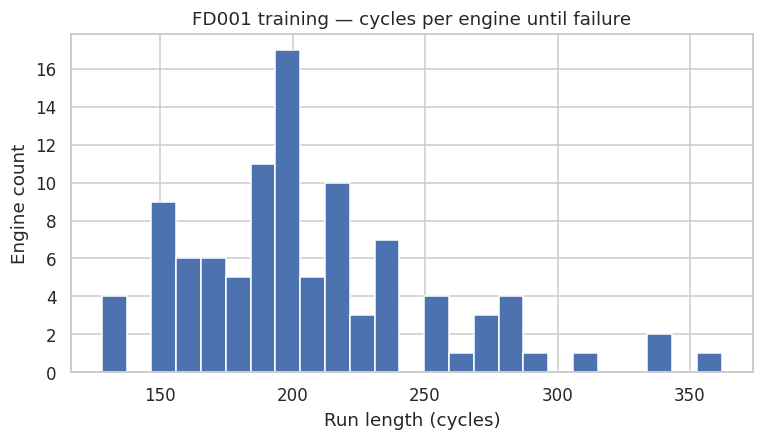

In [4]:
cycles = train.groupby("unit")["cycle"].agg(["min", "max", "count"])
cycles["life"] = cycles["max"] - cycles["min"] + 1
display(cycles.describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(cycles["life"], bins=25, edgecolor="white")
ax.set_xlabel("Run length (cycles)")
ax.set_ylabel("Engine count")
ax.set_title("FD001 training - cycles per engine until failure")
plt.show()

## 3. Sensor Variance Analysis: Which Channels Are Informative?

Not all 21 sensors help. Some channels exist in the CMAPSS simulation for physical completeness but barely vary, so they add no RUL signal. The table below ranks sensors from lowest to highest variance.

Sensors with variance below about 1e-6 are effectively constant. The cell also prints the `CONSTANT_SENSORS` list already hardcoded in `src/features.py`. Those two lists need to match. A mismatch would drop the wrong sensors and quietly corrupt everything downstream.

In [5]:
sensor_cols = [c for c in train.columns if c.startswith("sensor_")]
variances = train[sensor_cols].var()
variances_sorted = variances.sort_values()
display(variances_sorted.to_frame("variance"))

near_constant = variances_sorted[variances_sorted < 1e-6].index.tolist()
print("Near-zero variance sensors:", near_constant)
print("Project CONSTANT_SENSORS list:", CONSTANT_SENSORS)

,variance
sensor_1,0.000000e+00
sensor_19,0.000000e+00
sensor_18,0.000000e+00
sensor_10,0.000000e+00
sensor_16,1.926023e-34
sensor_5,3.155597e-30
sensor_6,1.929279e-06
sensor_15,1.406628e-03
sensor_8,5.038938e-03
sensor_13,5.172330e-03


Near-zero variance sensors: ['sensor_1', 'sensor_19', 'sensor_18', 'sensor_10', 'sensor_16', 'sensor_5']
Project CONSTANT_SENSORS list: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


## 4. Sensor Correlation Structure

Before I commit to a tree model, I want to know whether the informative sensors are redundant. The heatmap below shows pairwise Pearson correlations on a stratified subsample of training rows (sampling within each engine so long-lived engines do not dominate).

Highly correlated clusters mean XGBoost can split importance somewhat arbitrarily among related channels. SHAP attributions are more stable here than raw `feature_importances_`, which is why I use SHAP for interpretation later.

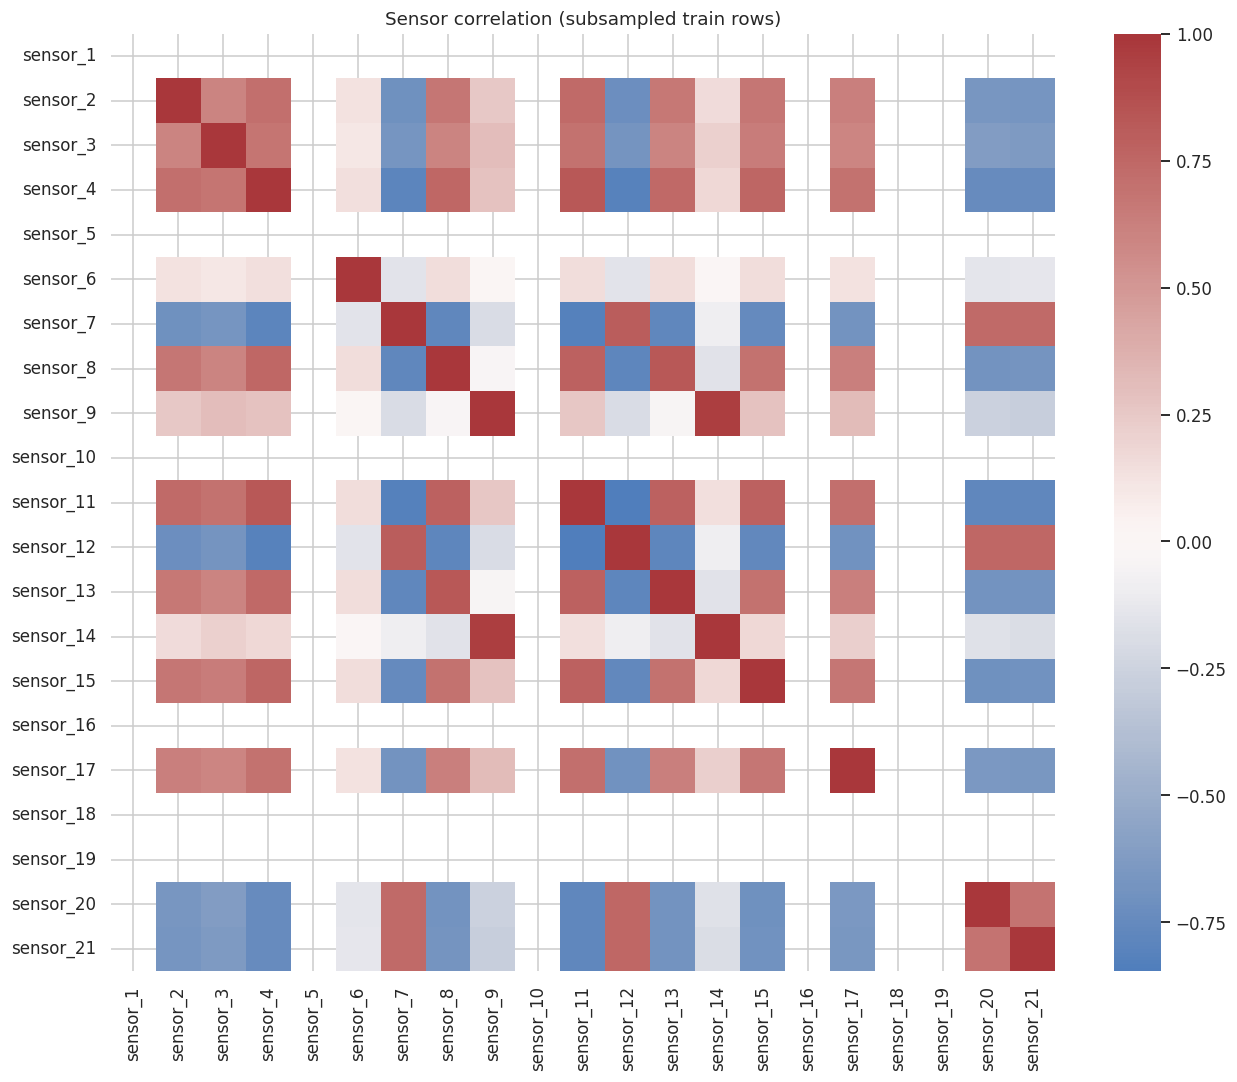

In [6]:
# Correlation among sensors (subsample per engine for speed)
parts = []
for _, g in train.groupby("unit"):
    step = max(1, len(g) // 50)
    parts.append(g.iloc[::step])
sample = pd.concat(parts, ignore_index=True)
corr = sample[sensor_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="vlag", center=0, ax=ax, square=False)
ax.set_title("Sensor correlation (subsampled train rows)")
plt.tight_layout()
plt.show()

## 5. RUL Label Distribution

The histogram below is clipped RUL across all training rows. The spike at 125 is every early-life cycle that hit the cap. The rest of the mass slopes toward 0 as engines accumulate late-stage cycles.

For operations, errors in the 0 to 50 cycle range matter most. The asymmetric scoring functions in the CMAPSS literature (Saxena et al. 2010) penalize late predictions more than early ones. RMSE treats both the same. I keep that in mind when I read published scores.

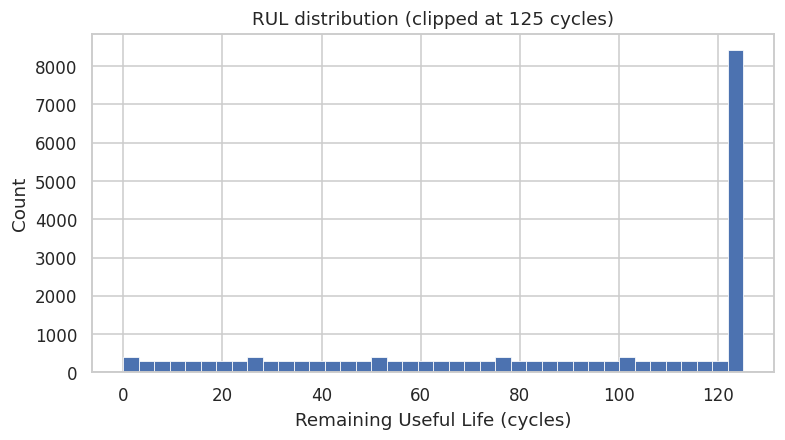

In [7]:
plot_rul_distribution(train_labeled)
plt.show()

## 6. Degradation Trajectories: The Physical Story

This is the plot that drives the feature design. Each line is one engine's sensor reading over its full life. I am looking for a consistent directional trend, visible across most engines, that separates a degrading engine from a healthy one.

Sensors with a clear rise or fall toward failure are the ones worth keeping. Flat or random-walk traces add noise. These trajectories should line up with the high-variance sensors from section 3.

## 6. Degradation Trajectories: The Physical Story

This is the plot that drives the feature design. Each line is one engine's sensor reading over its full life. I am looking for a consistent directional trend, visible across most engines, that separates a degrading engine from a healthy one.

Sensors with a clear rise or fall toward failure are the ones worth keeping. Flat or random-walk traces add noise. These trajectories should line up with the high-variance sensors from section 3.

The cycle-to-cycle jitter inside each trace is the noise a 30-cycle rolling mean is meant to smooth. A raw reading at cycle t is less useful than the average over the previous 30 cycles.

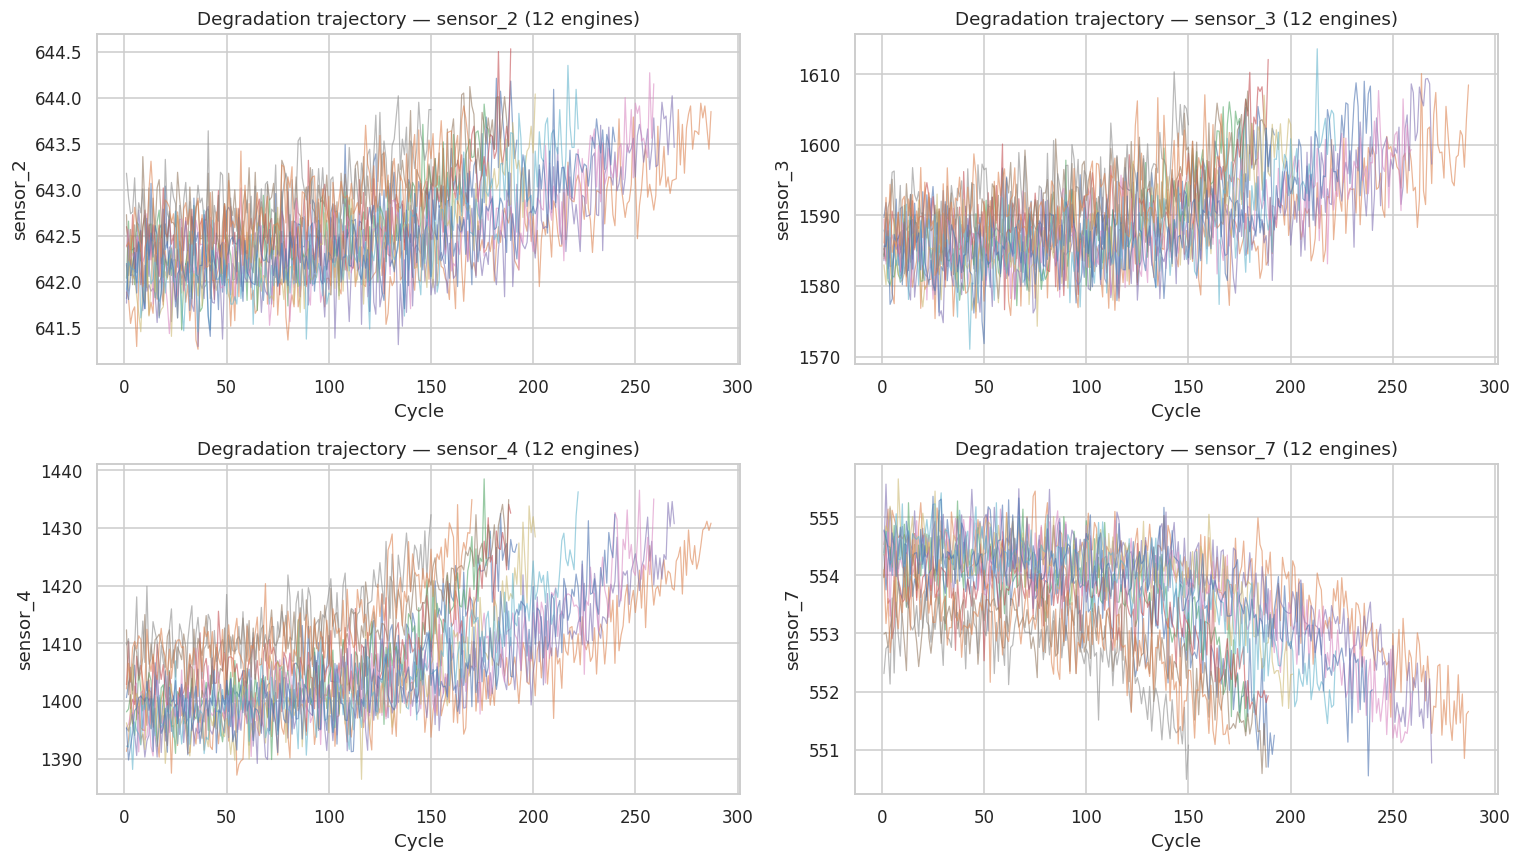

In [8]:
# Example degradation trajectories - pick sensors with visible variance
active_sensors = [s for s in sensor_cols if s not in CONSTANT_SENSORS][:4]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()
for ax, sensor in zip(axes, active_sensors):
    plot_degradation_trajectories(train, sensor, n_units=12, ax=ax)
plt.tight_layout()
plt.show()

## What this notebook established

Four facts from this EDA shape the rest of the project.

**Seven sensors carry no predictive signal.** Variance analysis shows `sensor_1`, `sensor_5`, `sensor_6`, `sensor_10`, `sensor_16`, `sensor_18`, and `sensor_19` are effectively constant across all 100 engines. Keeping them would add dimension without information. `src/features.py` drops them before any rolling features are built.

**Engine lifetimes vary, and that variation is real.** Run lengths range from 128 to 362 cycles, with a median around 200. That spread reflects operating stress and component tolerance, not a labeling bug. A constant guess of average life is a weak model. The comparison I actually report is XGBoost at 15.85 RMSE versus Ridge at 17.47 under the same protocol.

**The RUL cap at 125 cycles is justified by the data.** The RUL histogram has a sharp pile-up at 125, which is the piecewise-linear convention used throughout the CMAPSS literature. Without the cap, the loss is dominated by the plateau where early-life engines look the same. With the cap, late-stage examples carry more weight.

**Degradation is a trend, not a point.** Individual readings are noisy cycle to cycle, but the direction of change over about 30 cycles is visible in the sensors that actually vary. That is why I add rolling mean and rolling standard deviation. The 30-cycle window in `src/features.py` is a chosen smoothing horizon. It is not a measured fouling period.

### Next: `02_feature_engineering.ipynb`

I build the rolling features in `src/features.py` (`build_features()`), check that the engineered distributions look sensible, confirm they match the API's `readings_to_dataframe()` path, and export the processed training and test sets.